In [ ]:
# Runtime Restart runtime

In [5]:
!pip install -U kaggle

import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_9d85154487565b7831c060da46daea5e"

!kaggle datasets download -d apollo2506/eurosat-dataset
!unzip -q eurosat-dataset.zip
!ls

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.4/256.4 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 kB 13.9 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5
Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [01:12<00:00, 29.5MB/s]
100% 2.04G/2.04G [01:12<00:00, 30.3MB/s]
EuroSAT  EuroSATallBands  eurosat-dataset.zip  sample_data


In [4]:
import os

base_dir = "/content/EuroSAT"

for folder in os.listdir(base_dir):
    print(folder)

FileNotFoundError: [Errno 2] No such file or directory: '/content/EuroSAT'

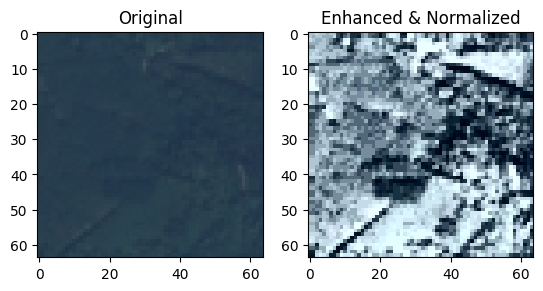

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Function to preprocess a single satellite image
def preprocess_satellite_image(image_path):
    # 1. Load Image (Fundamentals)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Image Enhancement (Topic 2)
    # Convert to YUV to equalize brightness without distorting colors
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    enhanced_img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    # 3. Normalization (Topic 1)
    normalized_img = enhanced_img / 255.0

    return img, normalized_img

# Test on one image from your unzipped folder
sample_path = 'EuroSAT/Forest/Forest_1.jpg' # Image path
original, processed = preprocess_satellite_image(sample_path)

# Display results
plt.subplot(1, 2, 1); plt.imshow(original); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(processed); plt.title("Enhanced & Normalized")
plt.show()

In [ ]:
# Calculate Spectral Index (VARI - Visible Atmospherically Resistant Index)

def calculate_vari(image):
    # Split bands (assuming image is normalized 0-1 from Phase 1)
    R = image[:, :, 0]
    G = image[:, :, 1]
    B = image[:, :, 2]

    # Formula for VARI
    vari = (G - R) / (G + R - B + 1e-6) # 1e-6 avoids division by zero
    return vari

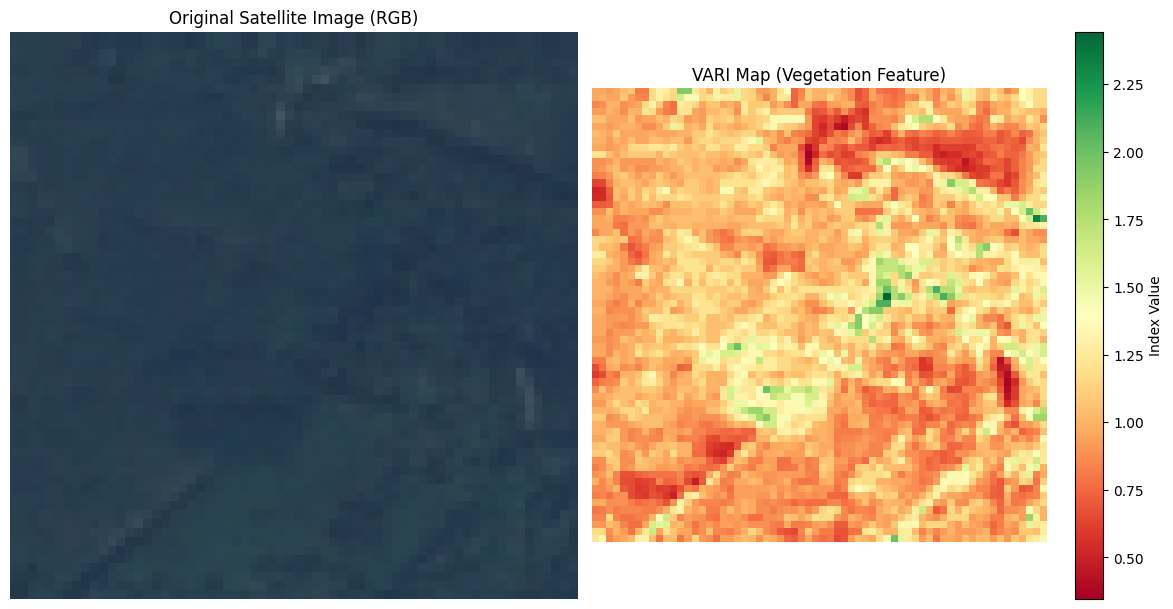

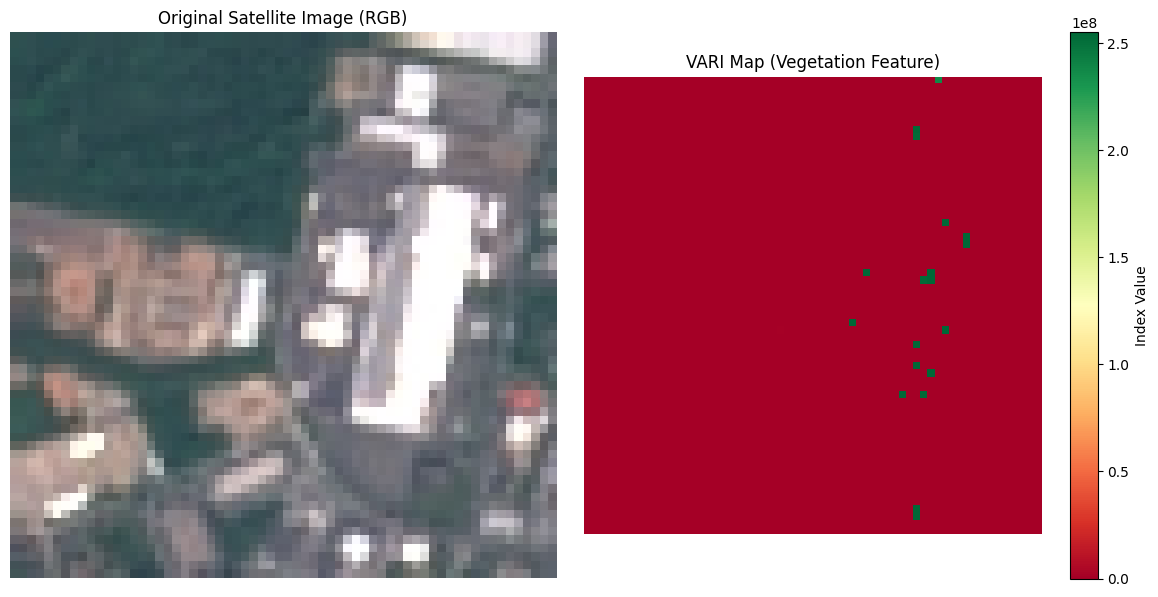

In [ ]:
# 1. Path to a sample image ('Forest')
sample_path = 'EuroSAT/Forest/Forest_1.jpg'

if os.path.exists(sample_path):
    # 2. Load and process
    original_bgr = cv2.imread(sample_path)
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    vari_map = calculate_vari(original_rgb)

    # 3. Visualization
    plt.figure(figsize=(12, 6))

    # Plot Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original Satellite Image (RGB)")
    plt.axis('off')

    # Plot VARI Map with a Colorbar
    plt.subplot(1, 2, 2)
    # Using 'RdYlGn' (Red-Yellow-Green) colormap is standard for vegetation
    im = plt.imshow(vari_map, cmap='RdYlGn')
    plt.title("VARI Map (Vegetation Feature)")
    plt.colorbar(im, label='Index Value')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"File not found at {sample_path}. Please check your folder structure.")


# 2. Path to a sample image ('Industrial')
sample_path = 'EuroSAT/Industrial/Industrial_1.jpg'

if os.path.exists(sample_path):
    # 2. Load and process
    original_bgr = cv2.imread(sample_path)
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    vari_map = calculate_vari(original_rgb)

    # 3. Visualization
    plt.figure(figsize=(12, 6))

    # Plot Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original Satellite Image (RGB)")
    plt.axis('off')

    # Plot VARI Map with a Colorbar
    plt.subplot(1, 2, 2)
    # Using 'RdYlGn' (Red-Yellow-Green) colormap is standard for vegetation
    im = plt.imshow(vari_map, cmap='RdYlGn')
    plt.title("VARI Map (Vegetation Feature)")
    plt.colorbar(im, label='Index Value')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"File not found at {sample_path}. Please check your folder structure.")

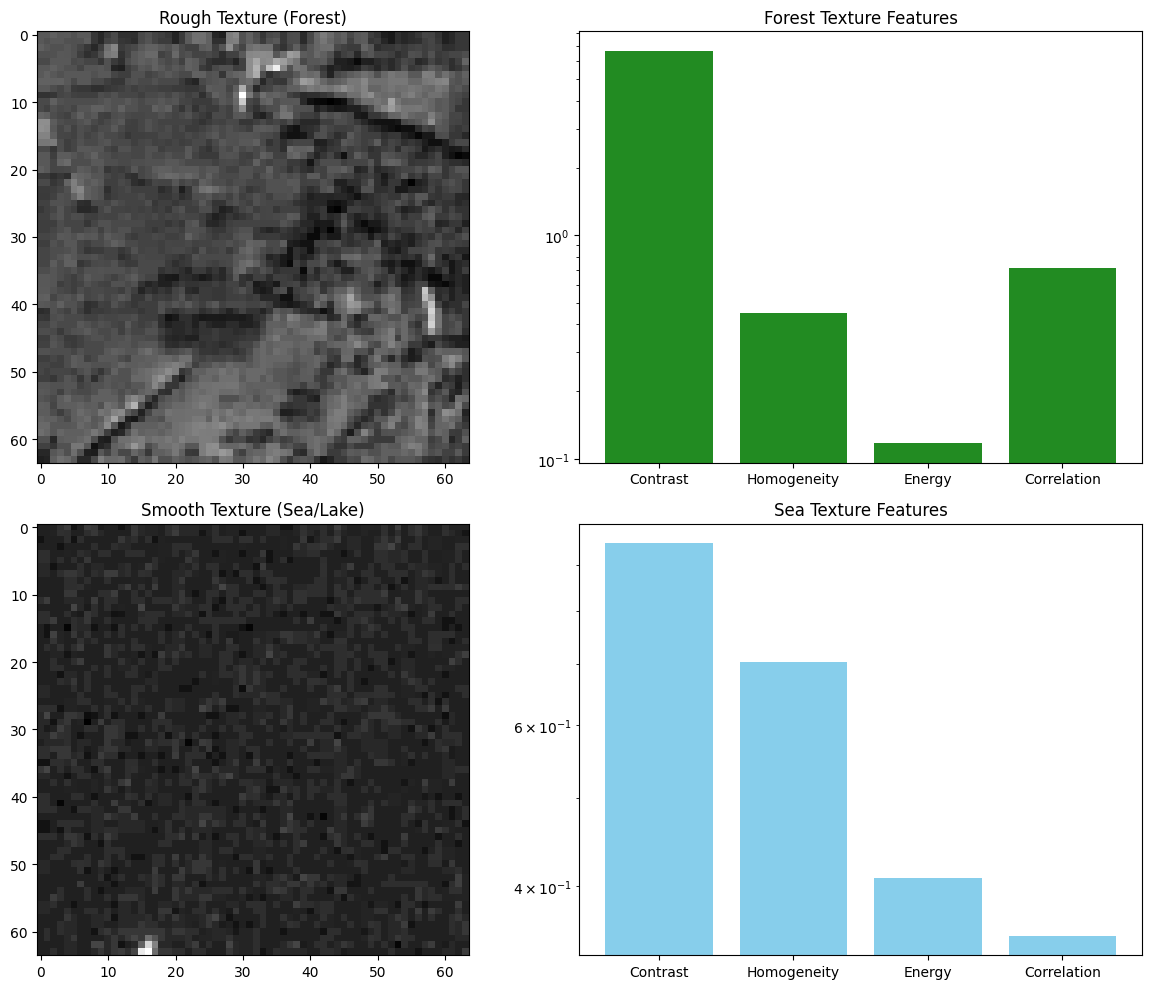

Forest Contrast: 6.67 | Sea Contrast: 0.95


In [ ]:
from skimage.feature import graycomatrix, graycoprops
from skimage import color, img_as_ubyte

def get_glcm_features(image_path):
    # 1. Load and convert to Grayscale (GLCM requires 1 channel)
    img = cv2.imread(image_path)
    img_gray = color.rgb2gray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    # 2. Convert to 8-bit unsigned integer (0-255)
    img_uint = img_as_ubyte(img_gray)

    # 3. Calculate GLCM (Distance=1, Angle=0 degrees)
    # We use a small distance because satellite tiles are small (64x64)
    glcm = graycomatrix(img_uint, distances=[1], angles=[0], levels=256,
                        symmetric=True, normed=True)

    # 4. Extract Properties
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    return img_gray, [contrast, homogeneity, energy, correlation]

# Select two different types of images to compare
path_rough = 'EuroSAT/Forest/Forest_1.jpg'
path_smooth = 'EuroSAT/SeaLake/SeaLake_1.jpg' # or 'Residential'

# Get features
gray_r, feat_r = get_glcm_features(path_rough)
gray_s, feat_s = get_glcm_features(path_smooth)

# --- Visualization ---
labels = ['Contrast', 'Homogeneity', 'Energy', 'Correlation']

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Show Forest
ax[0, 0].imshow(gray_r, cmap='gray')
ax[0, 0].set_title("Rough Texture (Forest)")
ax[0, 1].bar(labels, feat_r, color='forestgreen')
ax[0, 1].set_title("Forest Texture Features")
ax[0, 1].set_yscale('log') # Use log scale because Contrast is often much higher

# Show Sea/Smooth
ax[1, 0].imshow(gray_s, cmap='gray')
ax[1, 0].set_title("Smooth Texture (Sea/Lake)")
ax[1, 1].bar(labels, feat_s, color='skyblue')
ax[1, 1].set_title("Sea Texture Features")
ax[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Print values for verification
print(f"Forest Contrast: {feat_r[0]:.2f} | Sea Contrast: {feat_s[0]:.2f}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the Data Generator
# rescale=1./255 performs the Normalization we discussed in Topic 1
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    'EuroSAT/', # Path to your unzipped folder
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    'EuroSAT/',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Layer 1: Conv + Pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Deeper features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 3: High-level features
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(10, activation='softmax') # 10 classes in EuroSAT
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary() # This shows the structure of your "Brain"

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,962 (9.36 MB)

 Trainable params: 2,453,962 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10, # Start with 10 for a mini-project
    validation_data=val_generator
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


675/675 ━━━━━━━━━━━━━━━━━━━━ 193s 279ms/step - accuracy: 0.2840 - loss: 1.8317 - val_accuracy: 0.5511 - val_loss: 1.1684
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 178s 264ms/step - accuracy: 0.4905 - loss: 1.3087 - val_accuracy: 0.6620 - val_loss: 0.9770
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 178s 263ms/step - accuracy: 0.6190 - loss: 1.0499 - val_accuracy: 0.7213 - val_loss: 0.7529
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 179s 265ms/step - accuracy: 0.6757 - loss: 0.9145 - val_accuracy: 0.7357 - val_loss: 0.7234
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 181s 268ms/step - accuracy: 0.7090 - loss: 0.8185 - val_accuracy: 0.7602 - val_loss: 0.6420
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 175s 259ms/step - accuracy: 0.7464 - loss: 0.7207 - val_accuracy: 0.7870 - val_loss: 0.5698
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 185s 274ms/step - accuracy: 0.7654 - loss: 0.6815 - val_accuracy: 0.8113 - val_loss: 0.5458
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 195s 264ms/step - accuracy: 0.7870 - loss: 0.60

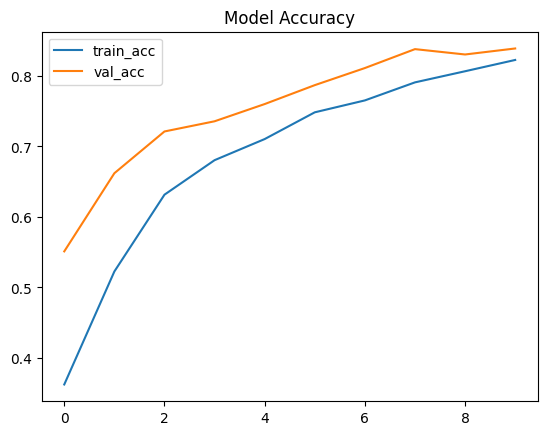

169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step


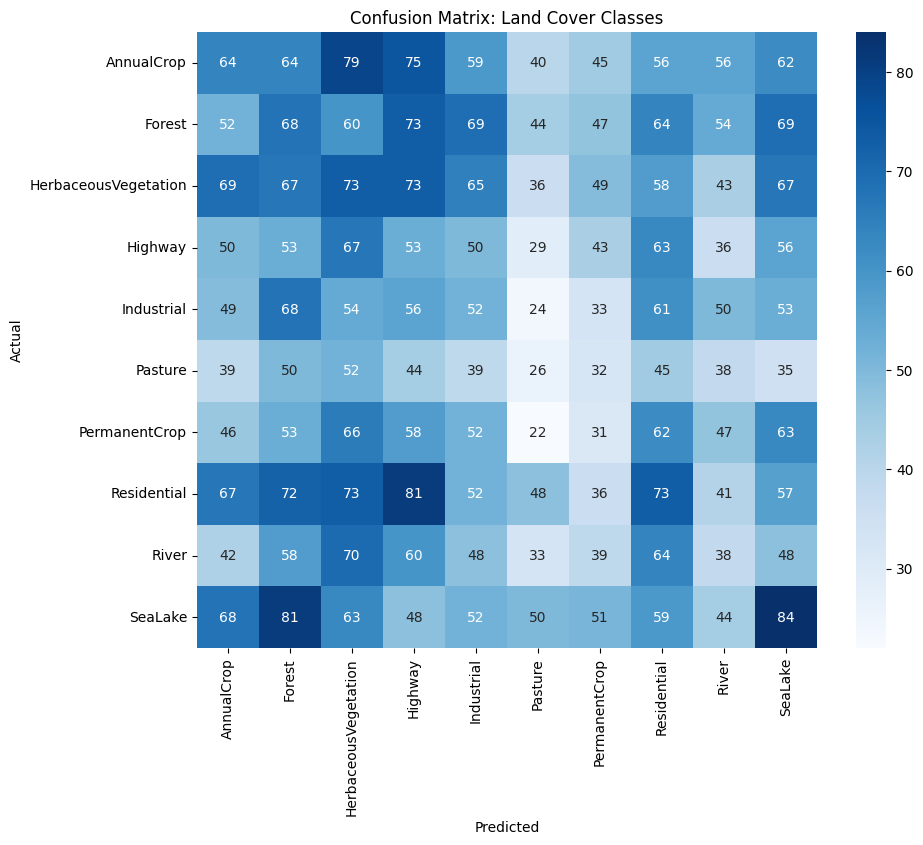

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Plot Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# To generate a Confusion Matrix, we need to predict on the validation set
import numpy as np
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# Plotting the Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(train_generator.class_indices.keys()),
            yticklabels=list(train_generator.class_indices.keys()))
plt.title("Confusion Matrix: Land Cover Classes")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [3]:
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_satellite_image(img_path, model):
    # 1. Load and Preprocess the image (Topic 1 & 3)
    img = image.load_img(img_path, target_size=(64, 64))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array /= 255.0 # Normalize (Topic 2)

    # 2. Make Prediction (Topic 7)
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0]) # Convert to probabilities

    predicted_class = class_names[np.argmax(predictions)]
    confidence = 100 * np.max(score)

    # 3. Visualization
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Test it on a random image from the dataset
test_img = 'EuroSAT/AnnualCrop/AnnualCrop_1137.jpg'
predict_satellite_image(test_img, model)

NameError: name 'model' is not defined